# Sudden Drift Detection

This notebook transfers the three drift-detector implementations into one Jupyter Notebook and applies them to the team's **sudden drift** synthetic data.

The three detectors are:

- ADWIN
- KSWIN
- Page-Hinkley

The sudden-drift dataset has a known true changepoint at **index 2000**, so the detectors can be compared using:

- detection delay
- false alarms per 10,000 observations
- missed detections

The notebook structure follows the same general workflow as the team's recurring-drift comparison notebook, but this version is for **Sudden Drift**.


## 1. Install River

River provides the ADWIN, KSWIN and Page-Hinkley implementations used by the detector wrappers.


In [1]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("river") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "river"])
else:
    print("River is already installed")


River is already installed


## 2. Import packages


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from river import drift
# Fixed seeds used throughout the experiment
SEEDS = [1, 2, 3, 4, 5]

## 3. Three detector implementations

These are the three detector wrappers transferred into the notebook.  
They all use the same interface: `detect(stream) -> list[int]`.


In [3]:
class ADWINDetector:
    """ADWIN drift detector wrapper."""

    def __init__(self, delta: float = 0.002):
        self.delta = delta

    def detect(self, stream: np.ndarray) -> list[int]:
        detector = drift.ADWIN(delta=self.delta)
        changepoints: list[int] = []

        for index, value in enumerate(stream):
            detector.update(float(value))

            if detector.drift_detected:
                changepoints.append(index)

        return changepoints


In [4]:
class KSWINDetector:
    """KSWIN drift detector wrapper."""

    def __init__(
        self,
        alpha: float = 0.005,
        window_size: int = 100,
        stat_size: int = 30,
        seed: int = 1,
    ):
        self.alpha = alpha
        self.window_size = window_size
        self.stat_size = stat_size
        self.seed = seed

    def detect(self, stream: np.ndarray) -> list[int]:
        detector = drift.KSWIN(
            alpha=self.alpha,
            window_size=self.window_size,
            stat_size=self.stat_size,
            seed=self.seed,
        )

        changepoints: list[int] = []

        for index, value in enumerate(stream):
            detector.update(float(value))

            if detector.drift_detected:
                changepoints.append(index)

        return changepoints

In [5]:
class PageHinkleyDetector:
    """Page-Hinkley drift detector wrapper."""

    def __init__(
        self,
        min_instances: int = 30,
        delta: float = 0.005,
        threshold: float = 50.0,
        alpha: float = 0.9999,
        mode: str = "both",
    ):
        self.min_instances = min_instances
        self.delta = delta
        self.threshold = threshold
        self.alpha = alpha
        self.mode = mode

    def detect(self, stream: np.ndarray) -> list[int]:
        detector = drift.PageHinkley(
            min_instances=self.min_instances,
            delta=self.delta,
            threshold=self.threshold,
            alpha=self.alpha,
            mode=self.mode,
        )

        changepoints: list[int] = []

        for index, value in enumerate(stream):
            detector.update(float(value))

            if detector.drift_detected:
                changepoints.append(index)

        return changepoints


## 4. Load the sudden drift data

The team's current sudden-drift file is:

`data/synthetic/ac_demand_abrupt_drift.csv`

It contains two columns without a header:

1. observation index
2. synthetic demand value


In [6]:
from pathlib import Path
import pandas as pd

# Exact location of the sudden-drift dataset
DATA_PATH = Path(
    r"D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\data\synthetic\ac_demand_abrupt_drift.csv"
)

# Check whether the file exists
print("File exists:", DATA_PATH.exists())
print("Dataset path:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

# Load the dataset
data = pd.read_csv(
    DATA_PATH,
    header=None,
    names=["t", "y"]
)

print("Rows:", len(data))
print("Columns:", list(data.columns))

display(data.head())

File exists: True
Dataset path: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\data\synthetic\ac_demand_abrupt_drift.csv
Rows: 20000
Columns: ['t', 'y']


,t,y
0,0,7.661207
1,1,8.330237
2,2,7.044929
3,3,18.160370
4,4,8.906078


## 5. Define the known sudden changepoint

For the team synthetic abrupt/sudden dataset, the true changepoint is **2000**.


In [7]:
TRUE_CHANGEPOINT = 2000

print("True changepoint:", TRUE_CHANGEPOINT)


True changepoint: 2000


## 6. Plot the sudden drift data

The dashed vertical line shows the true changepoint.  
The plot is zoomed around the changepoint so the abrupt level change is easier to see.


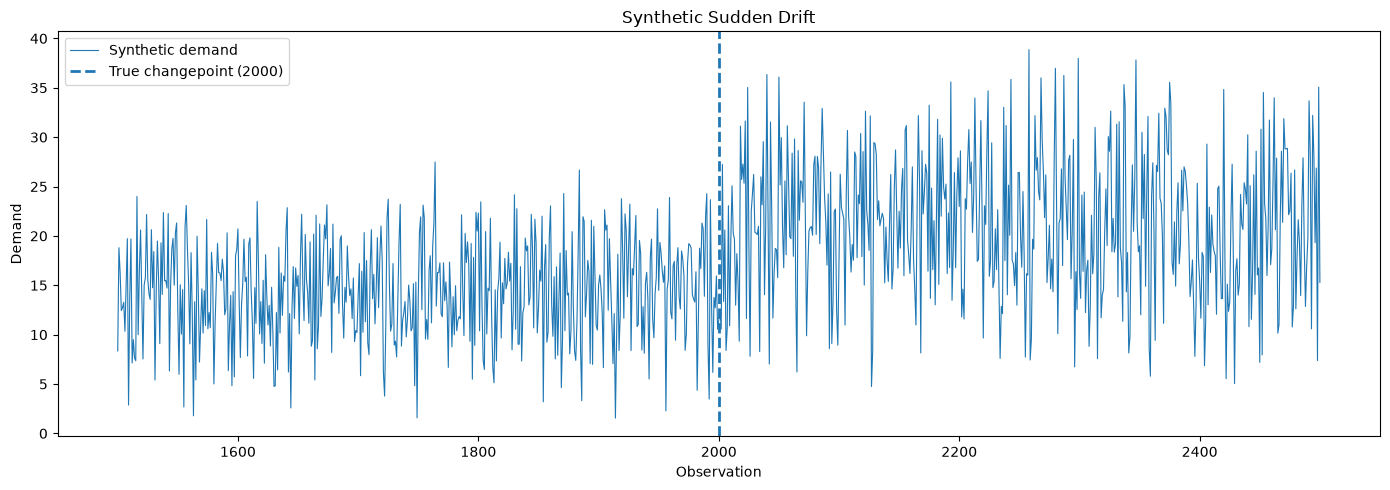

In [8]:
plot_start = 1500
plot_end = 2500

view = data[(data["t"] >= plot_start) & (data["t"] <= plot_end)]

plt.figure(figsize=(14, 5))
plt.plot(view["t"], view["y"], linewidth=0.8, label="Synthetic demand")
plt.axvline(
    TRUE_CHANGEPOINT,
    linestyle="--",
    linewidth=2,
    label=f"True changepoint ({TRUE_CHANGEPOINT})",
)

plt.title("Synthetic Sudden Drift")
plt.xlabel("Observation")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()


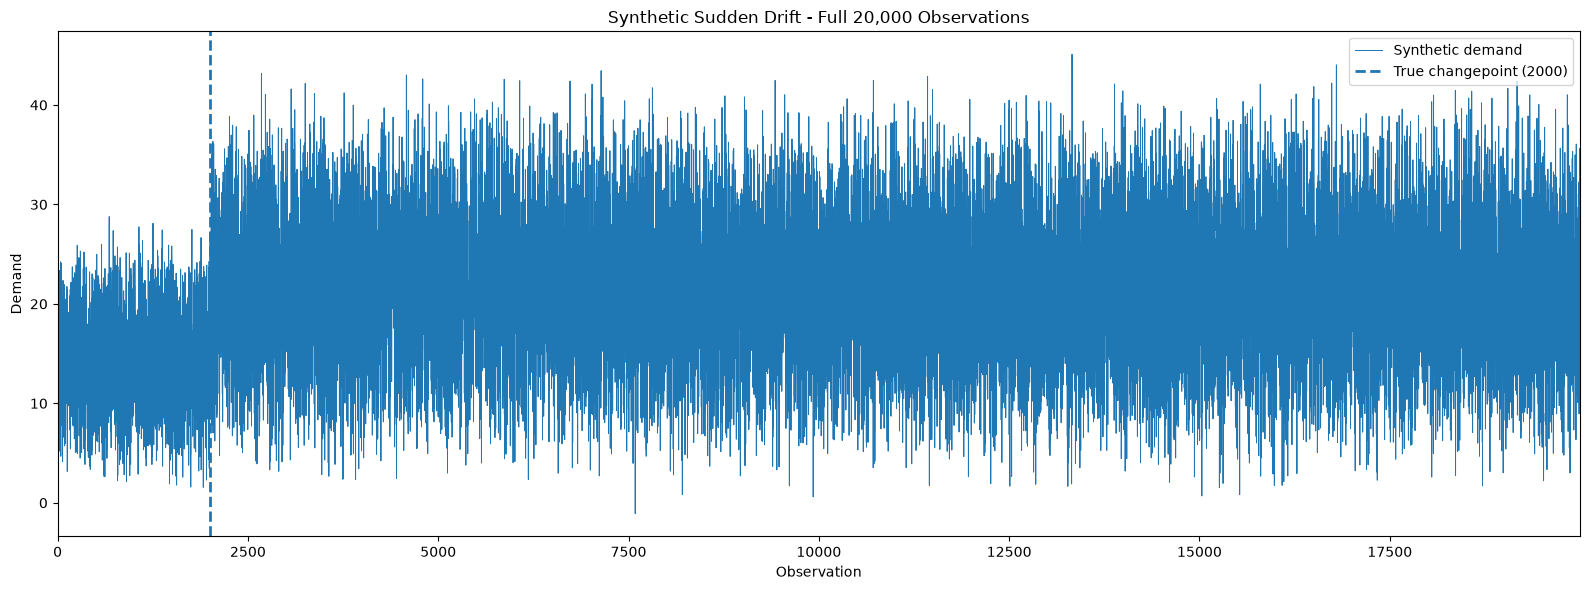

In [9]:
plt.figure(figsize=(16, 6))

plt.plot(
    data["t"],
    data["y"],
    linewidth=0.7,
    label="Synthetic demand"
)

plt.axvline(
    TRUE_CHANGEPOINT,
    linestyle="--",
    linewidth=2,
    label=f"True changepoint ({TRUE_CHANGEPOINT})"
)

plt.title("Synthetic Sudden Drift - Full 20,000 Observations")
plt.xlabel("Observation")
plt.ylabel("Demand")

plt.xlim(0, len(data) - 1)

plt.legend()
plt.tight_layout()
plt.show()

# 7. Run ADWIN

ADWIN uses `delta = 0.002`.


In [10]:
stream = data["y"].to_numpy(dtype=float)

adwin_detector = ADWINDetector(delta=0.002)
adwin_points = adwin_detector.detect(stream)

print("ADWIN detected changepoints:")
print(adwin_points)


ADWIN detected changepoints:
[2047]


# 8. Run KSWIN

KSWIN uses:

- alpha = 0.005
- window size = 100
- statistic size = 30


In [11]:
# 8. Run KSWIN

kswin_detector = KSWINDetector(
    alpha=0.005,
    window_size=100,
    stat_size=30,
    seed=SEEDS[0],
)

kswin_points = kswin_detector.detect(stream)

print(f"KSWIN demonstration seed: {SEEDS[0]}")
print("KSWIN detected changepoints:")
print(kswin_points)

KSWIN demonstration seed: 1
KSWIN detected changepoints:
[259, 421, 599, 958, 1215, 1454, 2031, 2409, 2691, 3204, 3454, 4049, 4239, 4372, 4639, 4850, 5399, 5499, 5604, 5771, 6028, 7339, 7767, 7920, 8115, 8883, 9303, 9926, 10509, 11670, 11937, 12170, 12696, 13179, 13732, 15499, 16201, 16394, 17865, 18031, 18239, 19135, 19305, 19438, 19551]


# 9. Run Page-Hinkley

Page-Hinkley uses:

- minimum instances = 30
- delta = 0.005
- threshold = 50
- alpha = 0.9999
- mode = both


In [12]:
ph_detector = PageHinkleyDetector(
    min_instances=30,
    delta=0.005,
    threshold=50.0,
    alpha=0.9999,
    mode="both",
)

ph_points = ph_detector.detect(stream)

print("Page-Hinkley detected changepoints:")
print(ph_points)


Page-Hinkley detected changepoints:
[29, 218, 287, 371, 401, 461, 554, 612, 675, 705, 738, 803, 859, 943, 978, 1054, 1115, 1163, 1201, 1273, 1306, 1419, 1451, 1499, 1540, 1573, 1633, 1740, 1770, 1848, 1930, 2018, 2048, 2095, 2125, 2189, 2235, 2269, 2308, 2338, 2368, 2398, 2439, 2471, 2513, 2543, 2579, 2610, 2644, 2674, 2704, 2734, 2772, 2802, 2833, 2863, 2927, 2958, 2988, 3030, 3079, 3115, 3157, 3191, 3221, 3251, 3287, 3317, 3420, 3450, 3485, 3515, 3555, 3585, 3631, 3673, 3703, 3745, 3775, 3815, 3870, 3915, 3945, 4010, 4040, 4071, 4105, 4135, 4165, 4200, 4230, 4262, 4310, 4351, 4398, 4430, 4460, 4506, 4536, 4575, 4685, 4723, 4773, 4803, 4833, 4864, 4907, 4956, 5007, 5038, 5068, 5098, 5128, 5158, 5188, 5222, 5255, 5295, 5338, 5384, 5415, 5445, 5475, 5510, 5590, 5640, 5686, 5716, 5753, 5783, 5817, 5847, 5898, 5930, 5962, 6015, 6050, 6082, 6124, 6176, 6216, 6306, 6339, 6393, 6455, 6486, 6520, 6550, 6580, 6610, 6642, 6672, 6720, 6752, 6783, 6813, 6843, 6926, 6983, 7013, 7048, 7079, 7117, 7

# 10. Evaluate the detectors

For sudden drift:

- **Detection delay** = first detection at or after the true changepoint − true changepoint.
- **Pre-drift false alarms** = detections before index 2000.
- **False alarms / 10k** standardises the pre-drift false alarms.
- **Missed** = 1 if no detection occurs at or after the true changepoint, otherwise 0.


In [13]:
def evaluate_sudden(detector_name, detected_points):
    false_points = [p for p in detected_points if p < TRUE_CHANGEPOINT]
    post_drift = [p for p in detected_points if p >= TRUE_CHANGEPOINT]

    if post_drift:
        matched_detection = post_drift[0]
        delay = matched_detection - TRUE_CHANGEPOINT
        missed = 0
    else:
        matched_detection = np.nan
        delay = np.nan
        missed = 1

    false_alarm_rate = len(false_points) / TRUE_CHANGEPOINT * 10000

    return {
        "Detector": detector_name,
        "Drift Type": "Sudden",
        "True Changepoint": TRUE_CHANGEPOINT,
        "Detected Changepoint": matched_detection,
        "Detection Delay": delay,
        "Pre-drift False Alarms": len(false_points),
        "False Alarms / 10k": false_alarm_rate,
        "Missed": missed,
        "false_points": false_points,
    }


In [14]:
adwin_result = evaluate_sudden("ADWIN", adwin_points)
kswin_result = evaluate_sudden("KSWIN", kswin_points)
ph_result = evaluate_sudden("Page-Hinkley", ph_points)

single_run_results = pd.DataFrame([
    {k: v for k, v in adwin_result.items() if k != "false_points"},
    {k: v for k, v in kswin_result.items() if k != "false_points"},
    {k: v for k, v in ph_result.items() if k != "false_points"},
])

single_run_results


,Detector,Drift Type,True Changepoint,Detected Changepoint,Detection Delay,Pre-drift False Alarms,False Alarms / 10k,Missed
0,ADWIN,Sudden,2000,2047,47,0,0.0,0
1,KSWIN,Sudden,2000,2031,31,6,30.0,0
2,Page-Hinkley,Sudden,2000,2018,18,31,155.0,0


# 11. Plot matched and unmatched detections

For each detector:

- dashed vertical line = true changepoint
- dotted vertical line = matched detection
- dash-dot vertical lines = false alarms within the displayed range


In [15]:
def plot_detector_result(title, result):
    start = 1500
    end = 2500
    view = data[(data["t"] >= start) & (data["t"] <= end)]

    plt.figure(figsize=(14, 5))
    plt.plot(view["t"], view["y"], linewidth=0.8, label="Synthetic demand")

    plt.axvline(
        TRUE_CHANGEPOINT,
        linestyle="--",
        linewidth=2,
        label=f"True changepoint ({TRUE_CHANGEPOINT})",
    )

    detected = result["Detected Changepoint"]
    if not pd.isna(detected):
        plt.axvline(
            detected,
            linestyle=":",
            linewidth=2,
            label=f"Matched detection ({int(detected)})",
        )

    visible_false = [
        p for p in result["false_points"]
        if start <= p <= end
    ]

    for i, p in enumerate(visible_false):
        plt.axvline(
            p,
            linestyle="-.",
            alpha=0.7,
            label="False alarm" if i == 0 else None,
        )

    plt.title(title)
    plt.xlabel("Observation")
    plt.ylabel("Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()


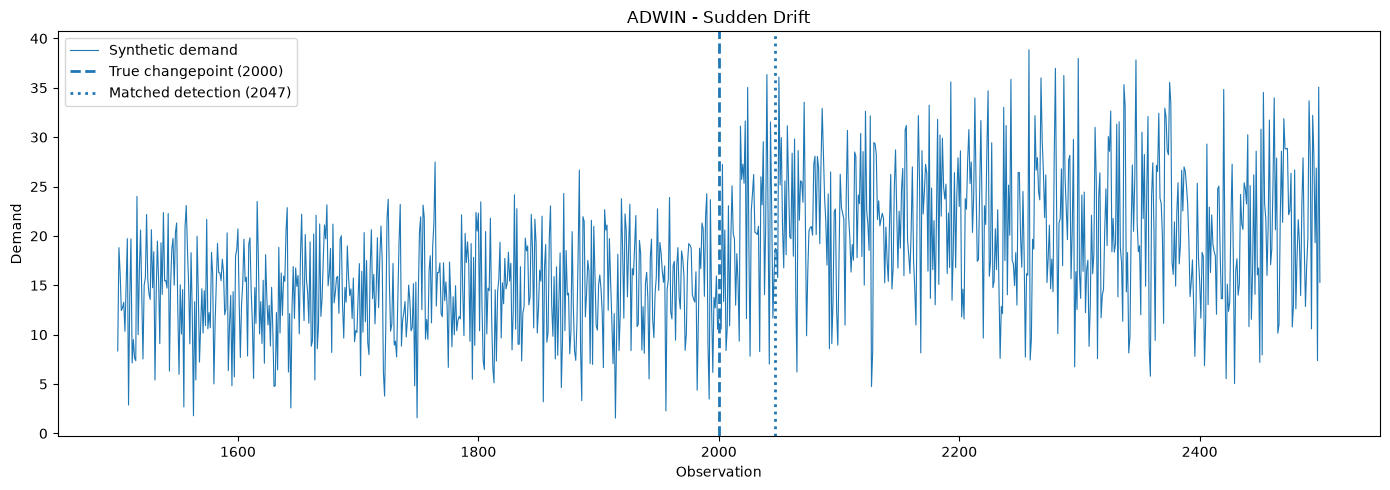

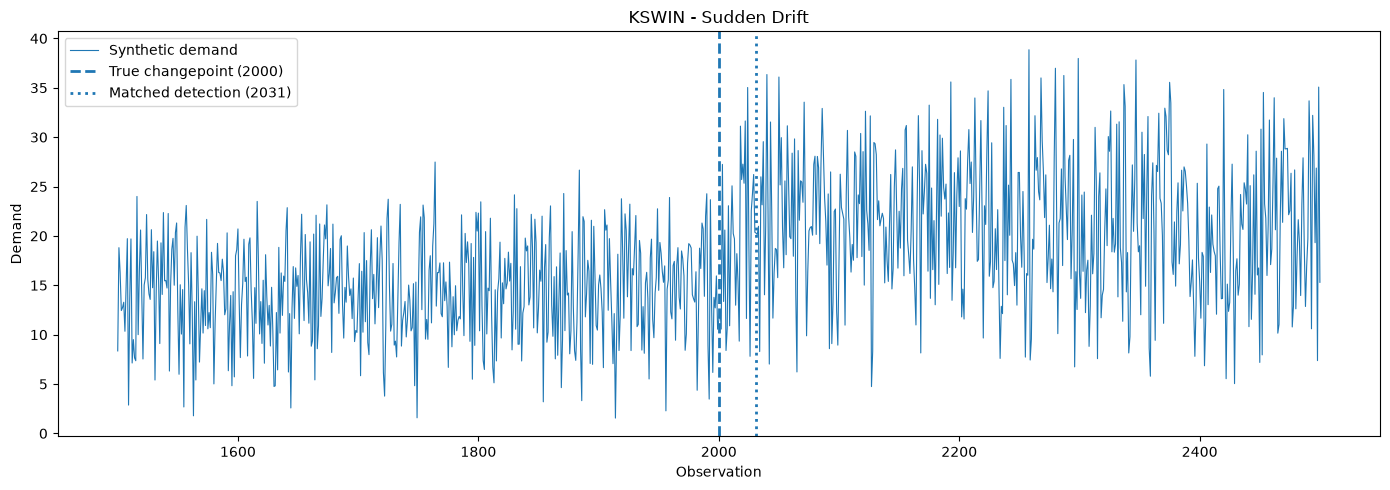

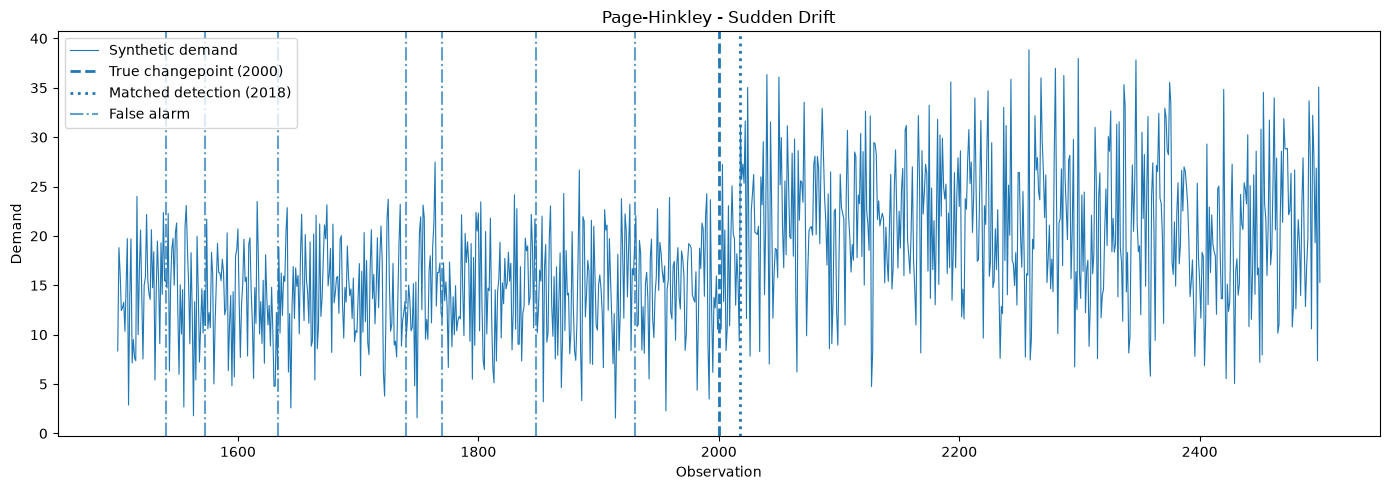

In [16]:
plot_detector_result("ADWIN - Sudden Drift", adwin_result)
plot_detector_result("KSWIN - Sudden Drift", kswin_result)
plot_detector_result("Page-Hinkley - Sudden Drift", ph_result)


# 12. Combined sudden-drift comparison plot

This plot places the true changepoint and each detector's matched detection on the same figure.


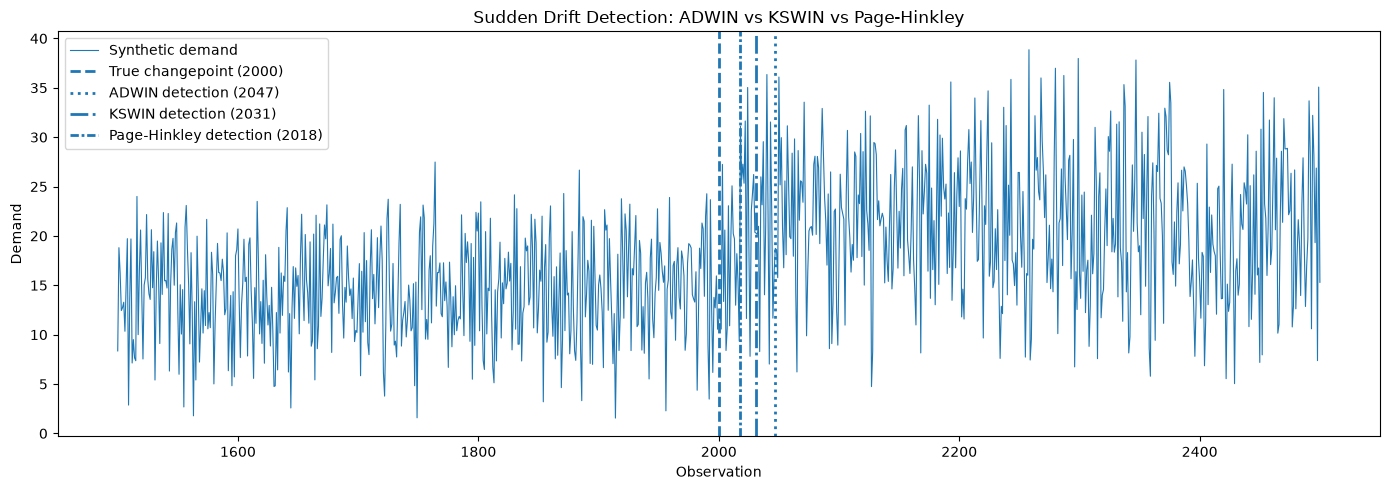

In [17]:
plt.figure(figsize=(14, 5))

view = data[(data["t"] >= 1500) & (data["t"] <= 2500)]
plt.plot(view["t"], view["y"], linewidth=0.8, label="Synthetic demand")

plt.axvline(
    TRUE_CHANGEPOINT,
    linestyle="--",
    linewidth=2,
    label=f"True changepoint ({TRUE_CHANGEPOINT})",
)

for result, style in [
    (adwin_result, ":"),
    (kswin_result, "-."),
    (ph_result, (0, (3, 1, 1, 1))),
]:
    p = result["Detected Changepoint"]
    if not pd.isna(p):
        plt.axvline(
            p,
            linestyle=style,
            linewidth=2,
            label=f"{result['Detector']} detection ({int(p)})",
        )

plt.title("Sudden Drift Detection: ADWIN vs KSWIN vs Page-Hinkley")
plt.xlabel("Observation")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()


# 13. Single-series comparison table

This table reports the three detectors on the current sudden-drift CSV.


In [18]:
threshold_text = {
    "ADWIN": "δ = 0.002",
    "KSWIN": "α = 0.005",
    "Page-Hinkley": "threshold = 50.0",
}

comparison_table = single_run_results[
    ["Detector", "Drift Type", "Detection Delay", "False Alarms / 10k", "Missed"]
].copy()

comparison_table["Threshold"] = comparison_table["Detector"].map(threshold_text)

comparison_table


,Detector,Drift Type,Detection Delay,False Alarms / 10k,Missed,Threshold
0,ADWIN,Sudden,47,0.0,0,δ = 0.002
1,KSWIN,Sudden,31,30.0,0,α = 0.005
2,Page-Hinkley,Sudden,18,155.0,0,threshold = 50.0


# 14. Comparison graphs


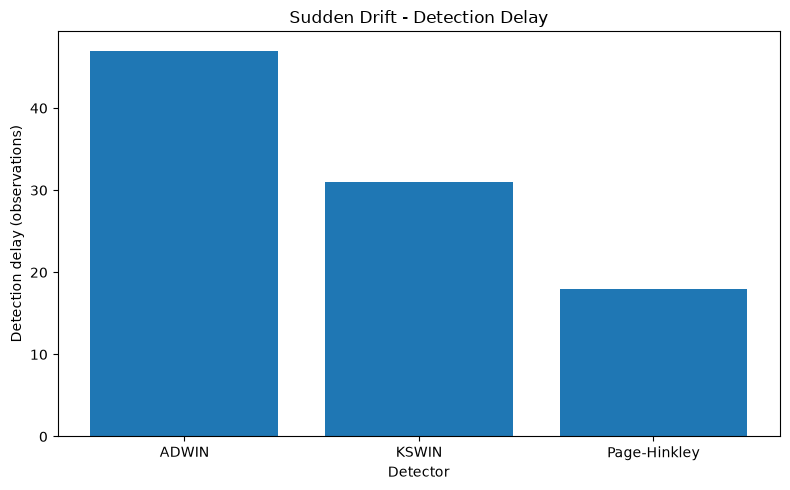

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_table["Detector"],
    comparison_table["Detection Delay"],
)
plt.title("Sudden Drift - Detection Delay")
plt.xlabel("Detector")
plt.ylabel("Detection delay (observations)")
plt.tight_layout()
plt.show()


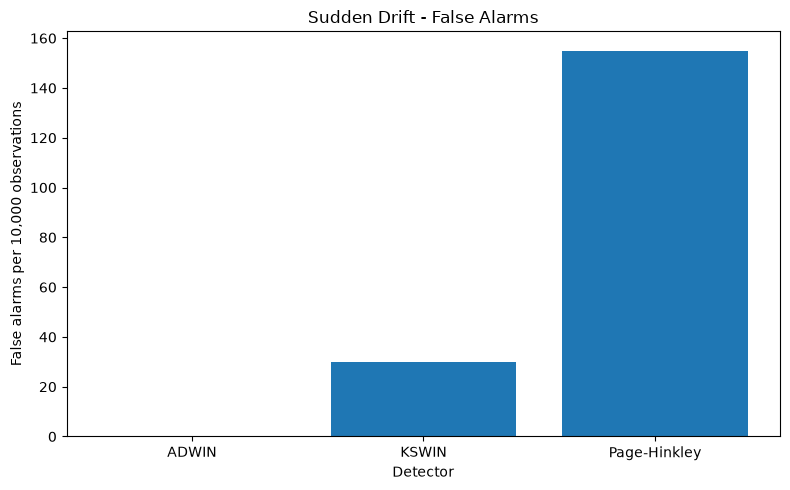

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_table["Detector"],
    comparison_table["False Alarms / 10k"],
)
plt.title("Sudden Drift - False Alarms")
plt.xlabel("Detector")
plt.ylabel("False alarms per 10,000 observations")
plt.tight_layout()
plt.show()


# 15. Five-Fixed-Seed T1 Benchmark Results

This section presents the final T1 synthetic benchmark results for the three drift detectors: **ADWIN, KSWIN, and Page-Hinkley**.

The benchmark uses **20,000 observations** and **five fixed seeds (1–5)** to improve reproducibility and reduce the effect of randomness.

Two conditions are evaluated:

- **Sudden drift:** a known concept drift is introduced at observation 2,000.
- **No-drift control:** no concept drift is introduced, so any detected changepoint is treated as a false alarm.

The final table reports detection delay, false alarms per 10,000 observations, missed detections, detector parameters, and the number of seeds.

In [21]:
# 15.1 Locate the final synthetic T1 benchmark table

from pathlib import Path
import pandas as pd

t1_candidates = [
    # Absolute project path
    Path(
        r"D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting"
    ) / "reports" / "results" / "synthetic_benchmark_T1.csv",

    # Relative paths
    Path("../../reports/results/synthetic_benchmark_T1.csv"),
    Path("../reports/results/synthetic_benchmark_T1.csv"),
    Path("reports/results/synthetic_benchmark_T1.csv"),
]

T1_PATH = next(
    (p for p in t1_candidates if p.exists()),
    None
)

if T1_PATH is None:
    print("Final T1 benchmark CSV not found.")
    print("Run scripts/benchmark_sudden_drift.py first.")
    t1_results = None
else:
    t1_results = pd.read_csv(T1_PATH)

    print("Loaded:", T1_PATH)
    print("Rows:", len(t1_results))
    print("Columns:", list(t1_results.columns))

    display(t1_results)

Loaded: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\reports\results\synthetic_benchmark_T1.csv
Rows: 6
Columns: ['Detector', 'Drift Type', 'Delay (mean ± sd)', 'False Alarms / 10k', 'Missed', 'Threshold / Parameters', 'Seeds']


,Detector,Drift Type,Delay (mean ± sd),False Alarms / 10k,Missed,Threshold / Parameters,Seeds
0,ADWIN,sudden,27.8 ± 17.5,0.0,0.0,delta=0.002,5
1,KSWIN,sudden,20.6 ± 8.6,13.0,0.0,alpha=0.005; window=100; stat=30,5
2,Page-Hinkley,sudden,18.8 ± 18.2,139.0,0.0,delta=0.005; threshold=50; alpha=0.9999; mode=...,5
3,ADWIN,none,NaN,0.1,NaN,delta=0.002,5
4,KSWIN,none,NaN,15.1,NaN,alpha=0.005; window=100; stat=30,5
5,Page-Hinkley,none,NaN,145.3,NaN,delta=0.005; threshold=50; alpha=0.9999; mode=...,5


In [22]:
# Simplified threshold display for the final T1 tables

def simplify_threshold(detector):
    if detector == "ADWIN":
        return "δ = 0.002"
    elif detector == "KSWIN":
        return "α = 0.005"
    elif detector == "Page-Hinkley":
        return "threshold = 50"
    return ""

In [23]:
# 15.2 Display sudden-drift benchmark results

if t1_results is not None:

    sudden_results = t1_results[
        t1_results["Drift Type"] == "sudden"
    ].copy()

    # Simplify the parameter column
    sudden_results["Threshold"] = sudden_results["Detector"].apply(
        simplify_threshold
    )

    # Keep only the final reporting columns
    sudden_results = sudden_results[
        [
            "Detector",
            "Drift Type",
            "Delay (mean ± sd)",
            "False Alarms / 10k",
            "Missed",
            "Threshold",
            "Seeds",
        ]
    ]

    display(sudden_results)

,Detector,Drift Type,Delay (mean ± sd),False Alarms / 10k,Missed,Threshold,Seeds
0,ADWIN,sudden,27.8 ± 17.5,0.0,0.0,δ = 0.002,5
1,KSWIN,sudden,20.6 ± 8.6,13.0,0.0,α = 0.005,5
2,Page-Hinkley,sudden,18.8 ± 18.2,139.0,0.0,threshold = 50,5


In [24]:
# 15.3 Display no-drift control results

if t1_results is not None:

    no_drift_results = t1_results[
        t1_results["Drift Type"] == "none"
    ].copy()

    # Simplify the parameter column
    no_drift_results["Threshold"] = no_drift_results["Detector"].apply(
        simplify_threshold
    )

    # Keep only the final reporting columns
    no_drift_results = no_drift_results[
        [
            "Detector",
            "Drift Type",
            "Delay (mean ± sd)",
            "False Alarms / 10k",
            "Missed",
            "Threshold",
            "Seeds",
        ]
    ]

    display(no_drift_results)

,Detector,Drift Type,Delay (mean ± sd),False Alarms / 10k,Missed,Threshold,Seeds
3,ADWIN,none,NaN,0.1,NaN,δ = 0.002,5
4,KSWIN,none,NaN,15.1,NaN,α = 0.005,5
5,Page-Hinkley,none,NaN,145.3,NaN,threshold = 50,5


In [25]:
# 15.4 Create the final presentation table

if t1_results is not None:

    final_t1 = t1_results.copy()

    final_t1["Drift Type"] = final_t1["Drift Type"].replace({
    "sudden": "Sudden",
    "none": "No Drift"
})

    # Simplified threshold display for presentation
    final_t1["Threshold"] = final_t1["Detector"].map({
        "ADWIN": "δ = 0.002",
        "KSWIN": "α = 0.005",
        "Page-Hinkley": "threshold = 50",
    })

    # Keep only the columns needed for the final T1 presentation table
    final_columns = [
        "Detector",
        "Drift Type",
        "Delay (mean ± sd)",
        "False Alarms / 10k",
        "Missed",
        "Threshold",
        "Seeds",
    ]

    final_t1 = final_t1[final_columns].copy()

    # Replace undefined values in the no-drift control with —
    final_t1 = final_t1.fillna("—")

    display(final_t1)

,Detector,Drift Type,Delay (mean ± sd),False Alarms / 10k,Missed,Threshold,Seeds
0,ADWIN,Sudden,27.8 ± 17.5,0.0,0.0,δ = 0.002,5
1,KSWIN,Sudden,20.6 ± 8.6,13.0,0.0,α = 0.005,5
2,Page-Hinkley,Sudden,18.8 ± 18.2,139.0,0.0,threshold = 50,5
3,ADWIN,No Drift,—,0.1,—,δ = 0.002,5
4,KSWIN,No Drift,—,15.1,—,α = 0.005,5
5,Page-Hinkley,No Drift,—,145.3,—,threshold = 50,5


In [26]:
# 15.5 Detector configurations used in the benchmark

parameter_table = pd.DataFrame([
    {
        "Detector": "ADWIN",
        "Parameters": "delta = 0.002"
    },
    {
        "Detector": "KSWIN",
        "Parameters": "alpha = 0.005, window_size = 100, stat_size = 30"
    },
    {
        "Detector": "Page-Hinkley",
        "Parameters": (
            "min_instances = 30, delta = 0.005, "
            "threshold = 50, alpha = 0.9999, mode = both"
        )
    }
])

display(parameter_table)

,Detector,Parameters
0,ADWIN,delta = 0.002
1,KSWIN,"alpha = 0.005, window_size = 100, stat_size = 30"
2,Page-Hinkley,"min_instances = 30, delta = 0.005, threshold =..."


# 16. Save notebook results

The single-series comparison is saved separately.  
The five-seed benchmark files remain generated by `scripts/benchmark_sudden_drift.py`.


In [27]:
RESULTS_DIR = Path(
    r"D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\reports\results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = RESULTS_DIR / "sudden_detector_notebook_single_series.csv"

comparison_table.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\reports\results\sudden_detector_notebook_single_series.csv
